In [1]:
# 라이브러리 불러오기

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_log_error, r2_score

In [2]:
%pip install koreanize_matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import koreanize_matplotlib

In [4]:
# 데이터셋 불러오기
bd_df = pd.read_csv('./data/bike_demand.csv')

- datetime: 자전거 대여 일시
- season: 계절 구분
    - 1: 12월 21일 ~ 3월 20일
    - 2: 3월 21일 ~ 6월 20일
    - 3: 6월 21일 ~ 9월 22일
    - 4: 9월 23일 ~ 12월 20일
- holiday: 공휴일 여부 (0: 평일, 1: 공휴일)
- workingday: 근무일 여부 (0: 주말/공휴일, 1: 근무일)
- weather: 날씨 상황 (1: 맑음, 2: 구름낌/안개, 3: 약간의 비/눈, 4: 폭우/폭설)
- temp: 섭씨 온도
- atemp: 체감 섭씨 온도
- humidity: 습도
- windspeed: 풍속
- casual: 비회원 이용자의 대여량
- registered: 정기권 회원 이용자의 대여량
- count: 총 대여량 (회원과 비회원의 대여량 합)

In [5]:
bd_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
bd_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [7]:
bd_df.shape

(10886, 12)

In [8]:
bd_df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [9]:
bd_df['humidity'].value_counts(ascending=True)

humidity
10      1
8       1
12      1
13      1
97      1
     ... 
70    259
87    289
83    316
94    324
88    368
Name: count, Length: 89, dtype: int64

In [10]:
bd_df = bd_df[bd_df['humidity'] > 0]
# 비나 눈이 왔을 때 습도가 0%일 수가 없기에 결측/이상치로 간주하여 제거

humidity 변수에서 습도가 0%인 데이터가 일부 존재하였다. 실제 환경에서 습도 0%는 매우 드문 값이며 센서 측정 오류일 가능성이 있다고 판단하여 해당 데이터를 이상치로 간주하고 제거하였다.

In [11]:
bd_df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000,10864.000000
mean,2.509665,0.028627,0.680228,1.415409,20.239523,23.663937,62.011782,12.789784,36.090666,155.814065,191.904731
std,1.115241,0.166762,0.466409,0.630784,7.796779,8.480258,19.061721,8.164754,49.987574,151.075130,181.174729
min,1.000000,0.000000,0.000000,1.000000,0.820000,0.760000,8.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,47.000000,7.001500,4.000000,36.000000,43.000000
50%,3.000000,0.000000,1.000000,1.000000,20.500000,24.240000,62.000000,12.998000,17.000000,119.000000,146.000000
75%,4.000000,0.000000,1.000000,2.000000,26.240000,31.060000,77.000000,16.997900,49.000000,223.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.000000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [12]:
bd_df['windspeed'].value_counts()

windspeed
0.0000     1313
8.9981     1119
11.0014    1056
12.9980    1041
7.0015     1034
15.0013     955
6.0032      871
16.9979     819
19.0012     675
19.9995     491
22.0028     370
23.9994     273
26.0027     234
27.9993     187
30.0026     111
31.0009      89
32.9975      80
35.0008      58
39.0007      26
36.9974      22
43.0006      12
40.9973      11
43.9989       8
46.0022       3
56.9969       2
47.9988       2
51.9987       1
50.0021       1
Name: count, dtype: int64

In [13]:
bd_df.info()

<class 'pandas.DataFrame'>
Index: 10864 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10864 non-null  str    
 1   season      10864 non-null  int64  
 2   holiday     10864 non-null  int64  
 3   workingday  10864 non-null  int64  
 4   weather     10864 non-null  int64  
 5   temp        10864 non-null  float64
 6   atemp       10864 non-null  float64
 7   humidity    10864 non-null  int64  
 8   windspeed   10864 non-null  float64
 9   casual      10864 non-null  int64  
 10  registered  10864 non-null  int64  
 11  count       10864 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1.1 MB


In [14]:
bd_df['datetime'] = pd.to_datetime(bd_df['datetime'])

In [15]:
bd_df['year'] = bd_df['datetime'].dt.year
bd_df['month'] = bd_df['datetime'].dt.month
bd_df['day'] = bd_df['datetime'].dt.day
bd_df['hour'] = bd_df['datetime'].dt.hour
bd_df['dayofweek'] = bd_df['datetime'].dt.dayofweek

In [16]:
bd_df['hour'] = bd_df['datetime'].dt.hour

In [17]:
bd_df.isnull().sum().sum()

np.int64(0)

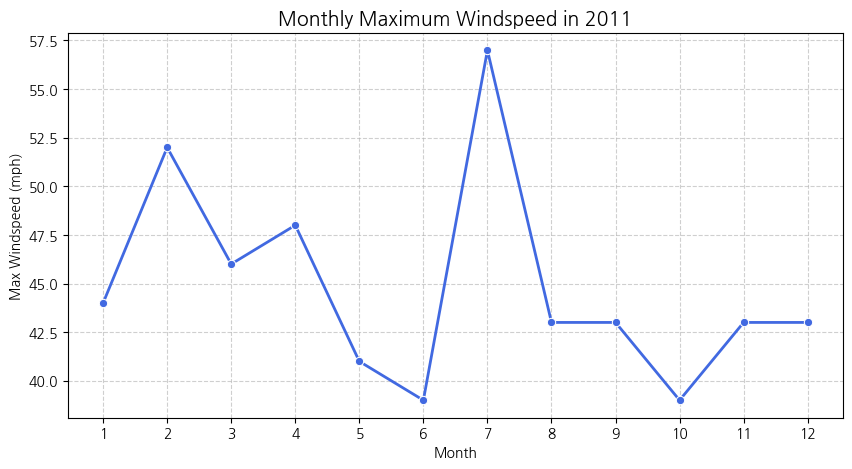

In [18]:
df_max_wind = bd_df.groupby('month')['windspeed'].max().reset_index()

# 2. 라인 플롯 그리기
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_max_wind, x='month', y='windspeed', marker='o', color='royalblue', linewidth=2)

plt.title('Monthly Maximum Windspeed in 2011', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Max Windspeed (mph)')
plt.xticks(range(1, 13)) # 1월부터 12월까지 다 표시
plt.grid(True, linestyle='--', alpha=0.6) # 눈금선 추가로 가독성 높이기
plt.show()

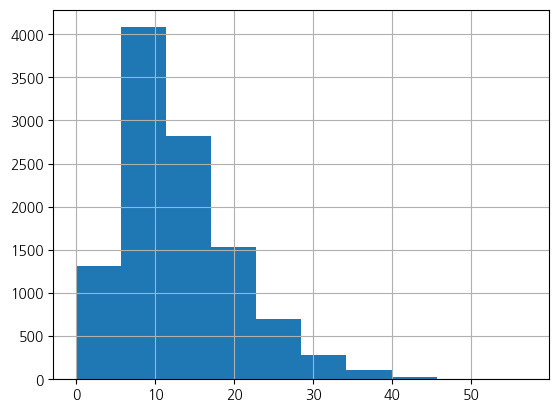

In [19]:
bd_df['windspeed'].hist()
plt.show()

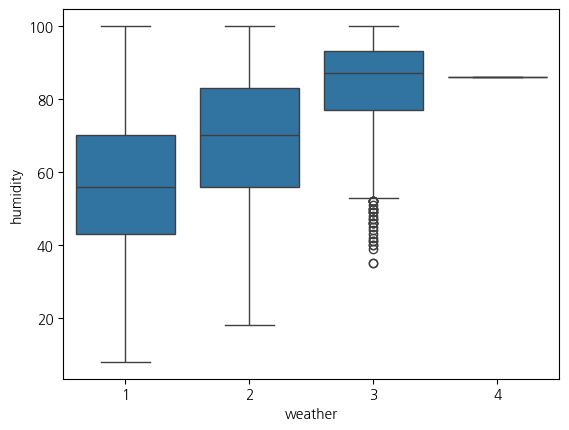

In [20]:
sns.boxplot(data=bd_df,
            x='weather',
            y='humidity')
plt.show()

C:\Users\hagjoon\AppData\Local\Temp\ipykernel_2768\2594908863.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=bd_df, x='weather', y='humidity', palette='muted')


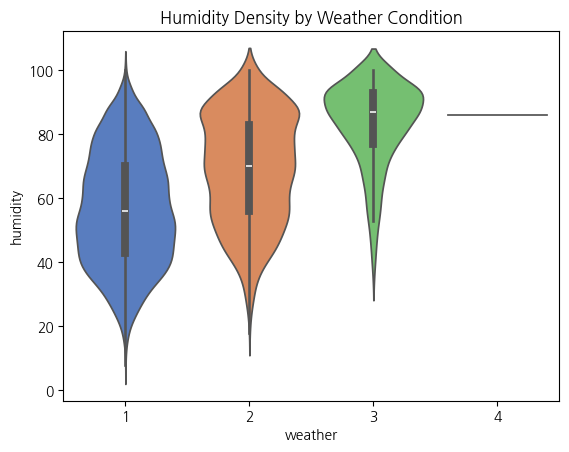

In [21]:
sns.violinplot(data=bd_df, x='weather', y='humidity', palette='muted')
plt.title('Humidity Density by Weather Condition')
plt.show()

In [22]:
# 요일별
bd_df.groupby('dayofweek')['count'].mean()

dayofweek
0    190.390716
1    189.723847
2    188.411348
3    199.724363
4    197.844343
5    196.665404
6    180.839772
Name: count, dtype: float64

In [23]:
# 월별
bd_df.groupby('month')['count'].mean()

month
1      90.366516
2     110.003330
3     151.169511
4     184.160616
5     219.459430
6     242.031798
7     235.325658
8     234.118421
9     233.805281
10    227.699232
11    193.677278
12    175.614035
Name: count, dtype: float64

In [24]:
bd_df.groupby('hour')['count'].mean()

hour
0      55.253304
1      33.929360
2      22.948546
3      11.757506
4       6.407240
5      19.804878
6      76.400881
7     213.504405
8     363.471366
9     222.215859
10    175.440529
11    211.114537
12    256.997802
13    258.327473
14    243.951648
15    254.826374
16    317.021978
17    469.551648
18    431.626374
19    315.848352
20    228.936264
21    173.690110
22    133.795604
23     89.646154
Name: count, dtype: float64

In [25]:
bd_df.groupby('season')['count'].mean()

season
1    117.070195
2    215.251372
3    234.417124
4    198.988296
Name: count, dtype: float64

- 12월 21일 ~ 3월 20일 인 경우 자전거 대여량의 평균이 다른 계절보다 적게 나타난다.

In [26]:
bd_df.groupby('holiday')['count'].mean()

holiday
0    192.082346
1    185.877814
Name: count, dtype: float64

In [27]:
bd_df.groupby('workingday')['count'].mean()

workingday
0    188.506621
1    193.502165
Name: count, dtype: float64

In [28]:
bd_df.groupby('weather')['count'].mean()

weather
1    205.236791
2    179.030720
3    121.109654
4    164.000000
Name: count, dtype: float64

- 비가 오는 날의 자전거 대여량이 감소해있다.

In [29]:
bd_df.groupby('temp')['count'].mean()

temp
0.82      77.714286
1.64      91.500000
2.46      43.000000
3.28      19.272727
4.10      50.272727
4.92      58.416667
5.74      53.233645
6.56      68.109589
7.38      67.754717
8.20      81.995633
9.02      73.616935
9.84      86.442177
10.66     92.560241
11.48    111.066298
12.30    120.002597
13.12    148.547753
13.94    146.666667
14.76    154.103672
15.58    180.782609
16.40    171.372796
17.22    183.971671
18.04    162.517028
18.86    159.692118
19.68    185.058824
20.50    204.672783
21.32    196.480663
22.14    184.717122
22.96    212.392405
23.78    235.650246
24.60    237.182051
25.42    222.062035
26.24    232.403974
27.06    211.025381
27.88    203.433036
28.70    257.679157
29.52    277.691218
30.34    303.193980
31.16    352.801653
31.98    318.683673
32.80    355.623762
33.62    348.323077
34.44    340.225000
35.26    342.934211
36.08    362.869565
36.90    318.717391
37.72    332.176471
38.54    238.857143
39.36    317.833333
41.00    294.000000
Name: count, dt

- 온도가 0~10도 까지 자전거 대여량이 적다

In [30]:
bd_df.groupby('atemp')['count'].mean()

atemp
0.760       1.000000
1.515       3.000000
2.275      38.000000
3.030      82.285714
3.790      39.062500
4.545      66.090909
5.305      63.200000
6.060      64.876712
6.820      56.380952
7.575      55.933333
8.335      58.444444
9.090      80.000000
9.850      81.456693
10.605     95.951807
11.365     90.442804
12.120    102.656410
12.880     89.518219
13.635     94.308017
14.395    116.483271
15.150    133.967456
15.910    135.474104
16.665    149.465608
17.425    149.038585
18.180    133.585366
18.940    149.555556
19.695    180.782609
20.455    171.372796
21.210    183.971671
21.970    162.517028
22.725    159.692118
23.485    185.058824
24.240    204.672783
25.000    195.109589
25.760    179.626478
26.515    212.392405
27.275    200.503546
28.030    133.312500
28.790    142.771429
29.545    151.046693
30.305    227.291429
31.060    308.323398
31.820    258.655518
32.575    331.746324
33.335    244.107143
34.090    295.183036
34.850    277.448763
35.605    312.144654
36.365 

In [31]:
bd_df.groupby('humidity')['count'].mean()

humidity
8       77.000000
10     107.000000
12      29.000000
13      17.000000
14      19.000000
          ...    
93      71.151220
94      88.475309
96      71.000000
97      64.000000
100     66.493243
Name: count, Length: 88, dtype: float64

In [32]:
bd_df.groupby('windspeed')['count'].mean()

windspeed
0.0000     161.101295
6.0032     148.003444
7.0015     169.852031
8.9981     175.772118
11.0014    202.437500
12.9980    202.440922
15.0013    212.002094
16.9979    216.112332
19.0012    218.309630
19.9995    225.670061
22.0028    185.918919
23.9994    220.516484
26.0027    229.247863
27.9993    219.363636
30.0026    217.171171
31.0009    208.955056
32.9975    184.075000
35.0008    230.155172
36.9974    197.045455
39.0007    181.538462
40.9973    189.363636
43.0006    137.916667
43.9989    192.375000
46.0022     67.333333
47.9988    140.500000
50.0021    171.000000
51.9987      5.000000
56.9969    269.500000
Name: count, dtype: float64

<Axes: xlabel='season', ylabel='count'>

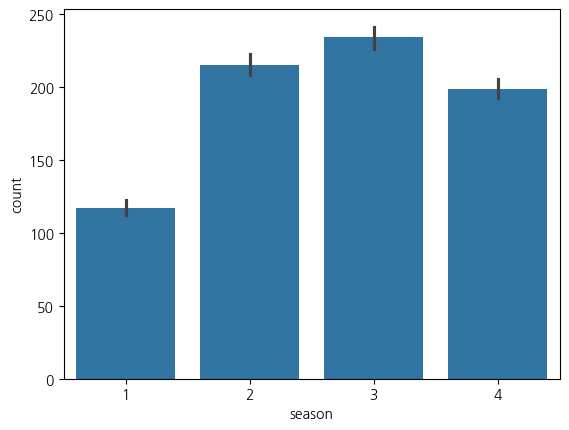

In [33]:
sns.barplot(x='season', y='count', data=bd_df)

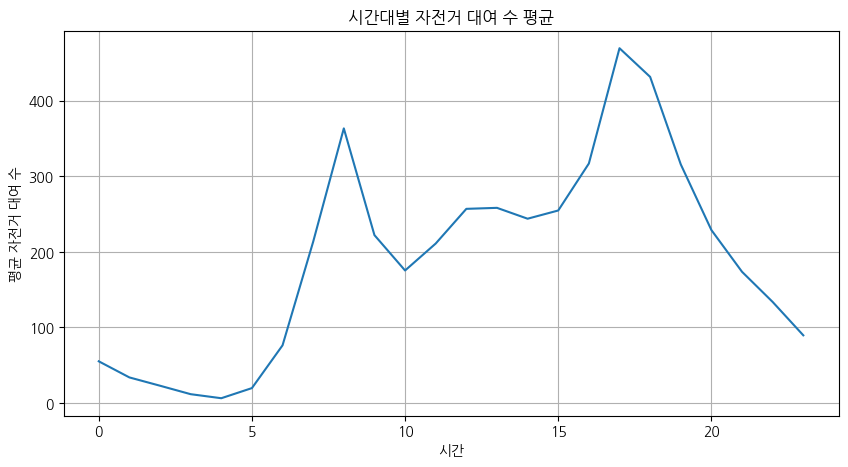

In [34]:
bd_df.groupby('hour')['count'].mean().plot(kind='line', figsize=(10,5))

plt.xlabel('시간')
plt.ylabel('평균 자전거 대여 수')
plt.title('시간대별 자전거 대여 수 평균')
plt.grid(True)
plt.show()

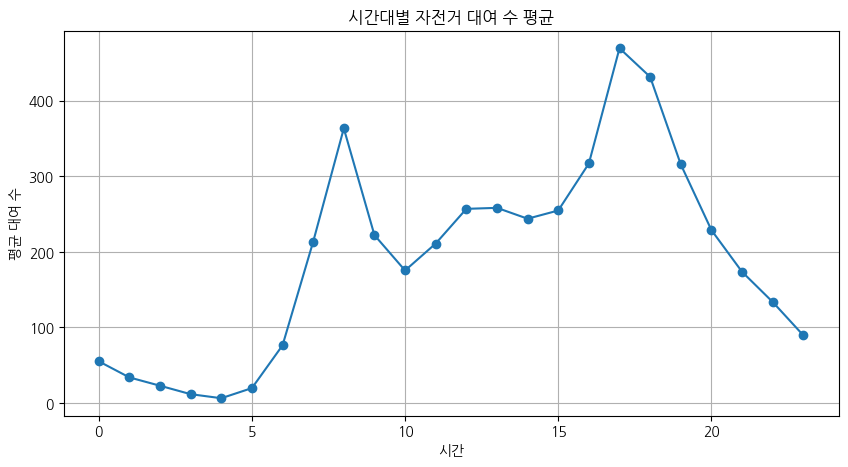

In [35]:
hourly = bd_df.groupby('hour')['count'].mean()

hourly.plot(
    figsize=(10,5),
    marker='o'
)
plt.title('시간대별 자전거 대여 수 평균')
plt.xlabel('시간')
plt.ylabel('평균 대여 수')
plt.grid()
plt.show()

- 새벽시간에는 자전거 대여가 적은것으로 보이며, 출근시간 때인 6~8시까지 대여 수가 증가하는 것을 보인다.
- 퇴근 시간인 17~19시에 가파르게 증가 하다 퇴근 시간 이후 점차 떨어지는 추세를 보인다.

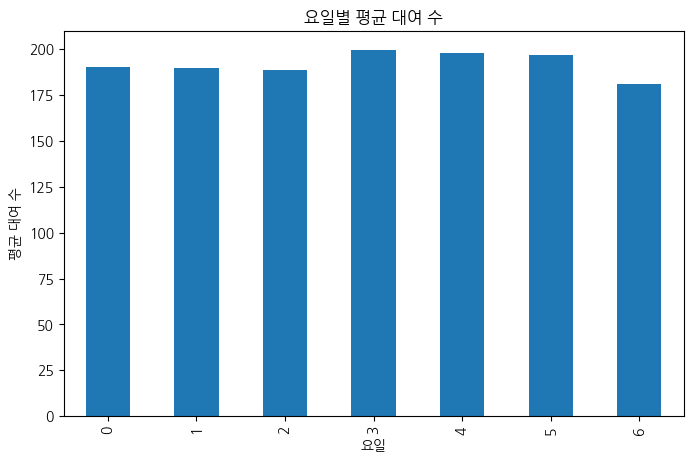

In [36]:
weekday = bd_df.groupby('dayofweek')['count'].mean()

weekday.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('요일별 평균 대여 수')
plt.xlabel('요일')
plt.ylabel('평균 대여 수')
plt.show()

- 요일별 평균 대여수는 큰 차이는 없는것으로 보인다.

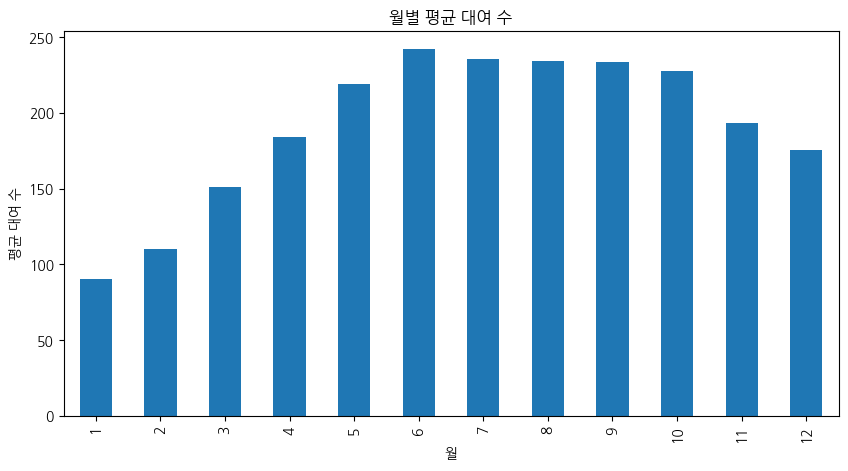

In [37]:
monthly = bd_df.groupby('month')['count'].mean()

monthly.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('월별 평균 대여 수')
plt.xlabel('월')
plt.ylabel('평균 대여 수')
plt.show()

-  6~10월까지 대여수가 많은것으로 보인다.

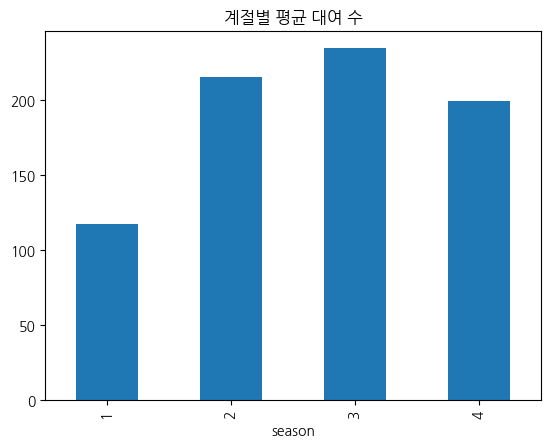

In [38]:
season_count = bd_df.groupby('season')['count'].mean()

season_count.plot(
    kind='bar'
)

plt.title('계절별 평균 대여 수')
plt.show()

- 2(여름), 3(가을) 여름과 가을철에 자전거를 대여하는 경우가 많은것으로 보인다.

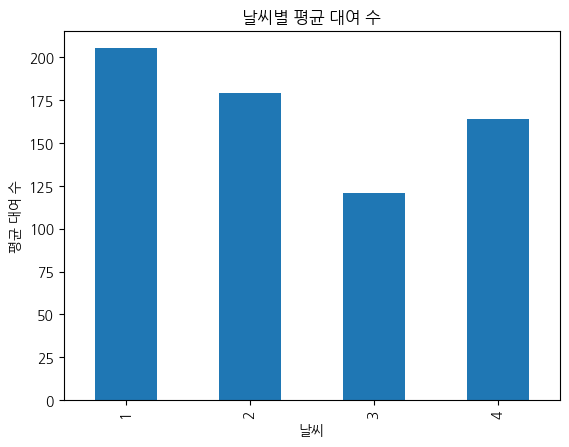

In [39]:
weather_count = bd_df.groupby('weather')['count'].mean()

weather_count.plot(
    kind='bar'
)

plt.title('날씨별 평균 대여 수')
plt.xlabel('날씨')
plt.ylabel('평균 대여 수')
plt.show()

- 맑은 날에 자전거 대여수가 크게 증가한다.

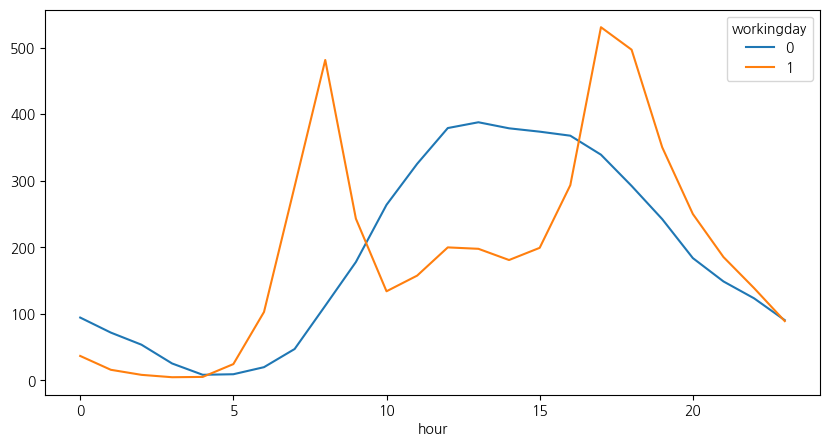

In [40]:
pivot = bd_df.pivot_table(
    values='count',
    index='hour',
    columns='workingday',
    aggfunc='mean'
)

pivot.plot(figsize=(10,5))
plt.show()

- 자전거 대여량은 시간뿐 아니라 평일/주말 여부에 따라 이용 목적이 달라진다.

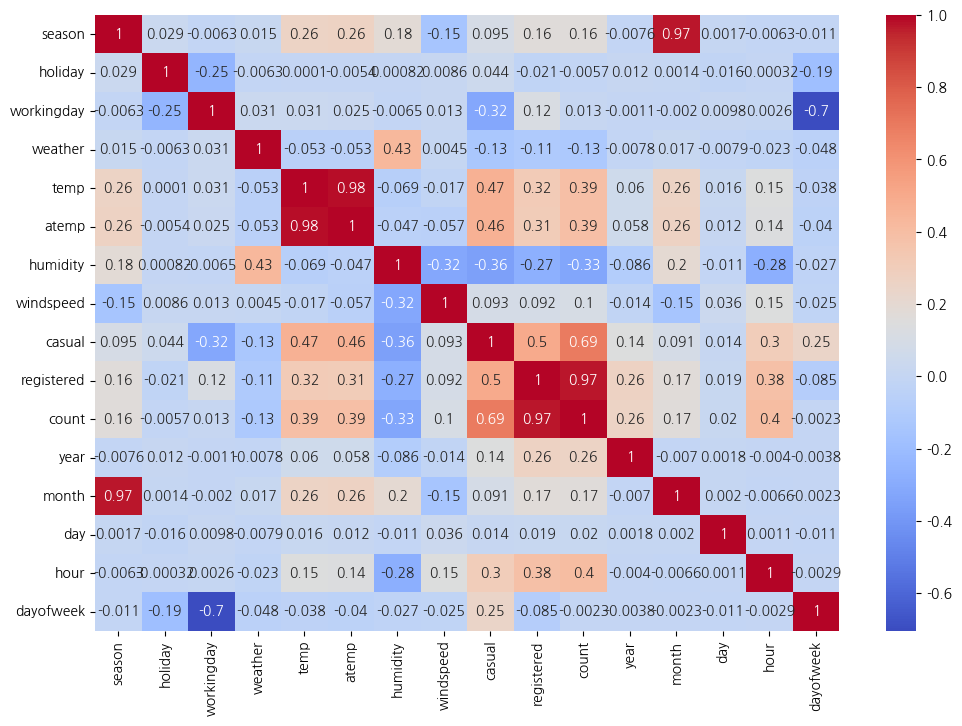

In [41]:
corr = bd_df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [42]:
corr_count = bd_df.corr(numeric_only=True)['count'].sort_values(ascending=False)

print(corr_count)

count         1.000000
registered    0.970904
casual        0.690077
hour          0.401366
temp          0.393893
atemp         0.389269
year          0.259054
month         0.165311
season        0.161409
windspeed     0.102502
day           0.019845
workingday    0.012860
dayofweek    -0.002298
holiday      -0.005711
weather      -0.125126
humidity     -0.326956
Name: count, dtype: float64


# 데이터 학습

### 데이터 분리

In [59]:
df_encoded = pd.get_dummies(
    bd_df,
    columns=[
        'weather',
        'hour',
        'month',
        'dayofweek'
    ],
    drop_first=True
)

In [60]:
df_encoded

,datetime,season,holiday,workingday,temp,atemp,humidity,windspeed,casual,registered,...,month_9,month_10,month_11,month_12,dayofweek_1,dayofweek_2,dayofweek_3,dayofweek_4,dayofweek_5,dayofweek_6
0,2011-01-01 00:00:00,1,0,0,9.84,14.395,81,0.0000,3,13,...,False,False,False,False,False,False,False,False,True,False
1,2011-01-01 01:00:00,1,0,0,9.02,13.635,80,0.0000,8,32,...,False,False,False,False,False,False,False,False,True,False
2,2011-01-01 02:00:00,1,0,0,9.02,13.635,80,0.0000,5,27,...,False,False,False,False,False,False,False,False,True,False
3,2011-01-01 03:00:00,1,0,0,9.84,14.395,75,0.0000,3,10,...,False,False,False,False,False,False,False,False,True,False
4,2011-01-01 04:00:00,1,0,0,9.84,14.395,75,0.0000,0,1,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,15.58,19.695,50,26.0027,7,329,...,False,False,False,True,False,True,False,False,False,False
10882,2012-12-19 20:00:00,4,0,1,14.76,17.425,57,15.0013,10,231,...,False,False,False,True,False,True,False,False,False,False
10883,2012-12-19 21:00:00,4,0,1,13.94,15.910,61,15.0013,4,164,...,False,False,False,True,False,True,False,False,False,False
10884,2012-12-19 22:00:00,4,0,1,13.94,17.425,61,6.0032,12,117,...,False,False,False,True,False,True,False,False,False,False


In [61]:
df_encoded.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'year', 'day',
       'weather_2', 'weather_3', 'weather_4', 'hour_1', 'hour_2', 'hour_3',
       'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10',
       'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16',
       'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22',
       'hour_23', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
       'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12',
       'dayofweek_1', 'dayofweek_2', 'dayofweek_3', 'dayofweek_4',
       'dayofweek_5', 'dayofweek_6'],
      dtype='str')

In [62]:
X = df_encoded.drop(['count', 'casual', 'registered','datetime','atemp','season'], axis=1)
X.columns

Index(['holiday', 'workingday', 'temp', 'humidity', 'windspeed', 'year', 'day',
       'weather_2', 'weather_3', 'weather_4', 'hour_1', 'hour_2', 'hour_3',
       'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10',
       'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16',
       'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22',
       'hour_23', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
       'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12',
       'dayofweek_1', 'dayofweek_2', 'dayofweek_3', 'dayofweek_4',
       'dayofweek_5', 'dayofweek_6'],
      dtype='str')

In [85]:
y = np.log1p(bd_df['count'])
y

0        2.833213
1        3.713572
2        3.496508
3        2.639057
4        0.693147
           ...   
10881    5.820083
10882    5.488938
10883    5.129899
10884    4.867534
10885    4.488636
Name: count, Length: 10864, dtype: float64

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [83]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [86]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [87]:
y_pred_log = rf.predict(X_test)

In [88]:
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

In [89]:
rmsle = np.sqrt(
    mean_squared_log_error(
        y_test_real,
        y_pred
    )
)

print("RMSLE:", rmsle)

RMSLE: 0.4582903152860781
